#### Import

In [1]:
import sys
import torch
sys.path.insert(0, '..')
from src.gnn.seed import set_seed
from src.gnn.data import load_and_preprocess_data
from src.gnn.training import compute_class_weights, train_with_early_stopping, print_test_evaluation
from src.gnn.visualization import plot_learning_curves
from src.gnn.losses import FocalLoss, DiceLoss
from src.gnn.models import GAT

#### Seed

In [2]:
set_seed(42)

#### Load data

In [3]:
data, device = load_and_preprocess_data('../data/processed/pyg_data.pt')

Device: cpu
Data(x=[203769, 165], edge_index=[2, 468710], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


#### Ablation Study

In [4]:
weight = compute_class_weights(data, device)

ablation_configs = {
    "1_CE_Weighted": {
        "criterion": torch.nn.CrossEntropyLoss(weight=weight),
        "lr": 0.005,
        "desc": "Baseline với class weight tĩnh"
    },
    "2_Focal_Alpha": {
        "criterion": FocalLoss(alpha=0.25, gamma=2.0), 
        "lr": 0.005,
        "desc": "Focal Loss chuẩn, alpha=0.25 cho illicit (không double-weighting)"
    },
    "3_DiceLoss": {
        "criterion": DiceLoss(),
        "lr": 0.001,
        "desc": "Dice Loss tự tối ưu overlap, không cần weight"
    }
}

ablation_results = {}


Class weights: licit=1.00, illicit=2.86


#### Ablation & Evaluate

Ablation: 1_CE_Weighted
Baseline với class weight tĩnh
Epoch 001: Train Loss=1.3331, Train F1=0.3887, Val F1=0.3945, Gap=-0.0058
Epoch 002: Train Loss=1.0942, Train F1=0.4674, Val F1=0.3889, Gap=0.0784
Epoch 003: Train Loss=0.7241, Train F1=0.5224, Val F1=0.3980, Gap=0.1243
Epoch 004: Train Loss=0.7211, Train F1=0.5559, Val F1=0.4054, Gap=0.1505
Epoch 005: Train Loss=0.6088, Train F1=0.5802, Val F1=0.4141, Gap=0.1662
Epoch 006: Train Loss=0.6243, Train F1=0.5887, Val F1=0.4188, Gap=0.1699
Epoch 007: Train Loss=0.6413, Train F1=0.5784, Val F1=0.4162, Gap=0.1623
Epoch 008: Train Loss=0.5657, Train F1=0.5674, Val F1=0.4157, Gap=0.1518
Epoch 009: Train Loss=0.5584, Train F1=0.5705, Val F1=0.4179, Gap=0.1527
Epoch 010: Train Loss=0.5159, Train F1=0.5903, Val F1=0.4258, Gap=0.1645
Epoch 011: Train Loss=0.5090, Train F1=0.6124, Val F1=0.4389, Gap=0.1735
Epoch 012: Train Loss=0.4803, Train F1=0.6316, Val F1=0.4573, Gap=0.1742
Epoch 013: Train Loss=0.4651, Train F1=0.6428, Val F1=0.4650, Gap=0.

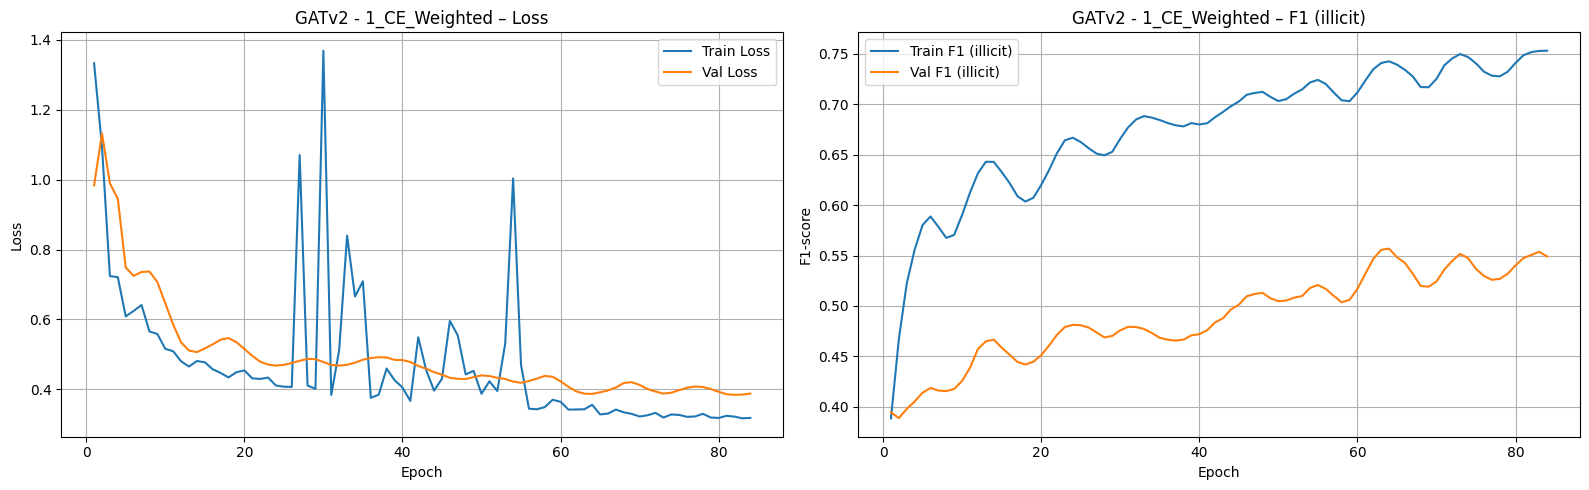


Test result for 1_CE_Weighted:
 1_CE_Weighted Set Evaluation
  Loss          : 0.4697
  Accuracy      : 0.7268
  Precision(ill): 0.1707
  Recall(ill)   : 0.8310
  F1(illicit)   : 0.2833
  F1(macro)     : 0.5573
  AUC-PR        : 0.6238

Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9839    0.7196    0.8312     15587
 Illicit (1)     0.1707    0.8310    0.2833      1083

    accuracy                         0.7268     16670
   macro avg     0.5773    0.7753    0.5573     16670
weighted avg     0.9311    0.7268    0.7956     16670

Confusion Matrix:
[[11216  4371]
 [  183   900]]
Ablation: 2_Focal_Alpha
Focal Loss chuẩn, alpha=0.25 cho illicit (không double-weighting)
Epoch 001: Train Loss=0.5581, Train F1=0.0335, Val F1=0.1712, Gap=-0.1378
Epoch 002: Train Loss=0.4291, Train F1=0.0174, Val F1=0.1727, Gap=-0.1552
Epoch 003: Train Loss=0.1845, Train F1=0.0683, Val F1=0.3462, Gap=-0.2779
Epoch 004: Train Loss=0.3015, Train F1=0.3725, Val 

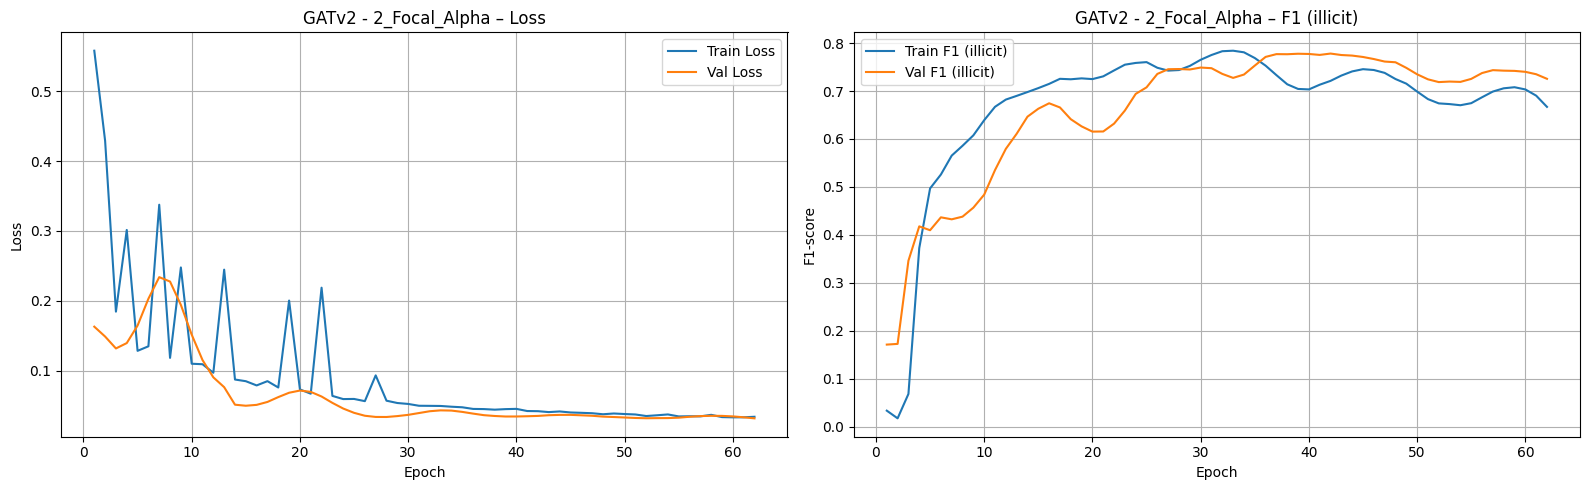


Test result for 2_Focal_Alpha:
 2_Focal_Alpha Set Evaluation
  Loss          : 0.0363
  Accuracy      : 0.9236
  Precision(ill): 0.4252
  Recall(ill)   : 0.5014
  F1(illicit)   : 0.4602
  F1(macro)     : 0.7095
  AUC-PR        : 0.4359

Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9649    0.9529    0.9589     15587
 Illicit (1)     0.4252    0.5014    0.4602      1083

    accuracy                         0.9236     16670
   macro avg     0.6951    0.7271    0.7095     16670
weighted avg     0.9299    0.9236    0.9265     16670

Confusion Matrix:
[[14853   734]
 [  540   543]]
Ablation: 3_DiceLoss
Dice Loss tự tối ưu overlap, không cần weight
Epoch 001: Train Loss=0.8112, Train F1=0.2904, Val F1=0.2883, Gap=0.0021
Epoch 002: Train Loss=0.7973, Train F1=0.3022, Val F1=0.3211, Gap=-0.0189
Epoch 003: Train Loss=0.7735, Train F1=0.3160, Val F1=0.3569, Gap=-0.0409
Epoch 004: Train Loss=0.7630, Train F1=0.3266, Val F1=0.3826, Gap=-0.0559
E

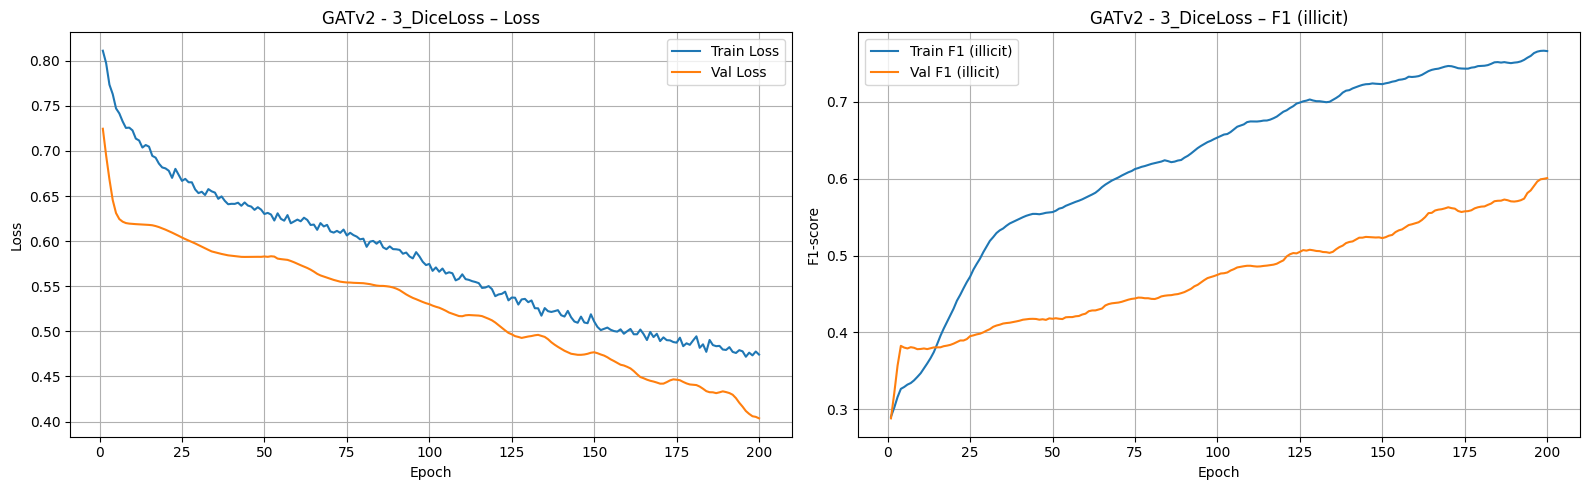


Test result for 3_DiceLoss:
 3_DiceLoss Set Evaluation
  Loss          : 0.7186
  Accuracy      : 0.7576
  Precision(ill): 0.1744
  Recall(ill)   : 0.7313
  F1(illicit)   : 0.2817
  F1(macro)     : 0.5679
  AUC-PR        : 0.5686

Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9760    0.7595    0.8542     15587
 Illicit (1)     0.1744    0.7313    0.2817      1083

    accuracy                         0.7576     16670
   macro avg     0.5752    0.7454    0.5679     16670
weighted avg     0.9239    0.7576    0.8170     16670

Confusion Matrix:
[[11838  3749]
 [  291   792]]


In [6]:
for name, config in ablation_configs.items():
    print(f"Ablation: {name}")
    print(f"{config['desc']}")
    print(f"{'='*70}")
    
    set_seed(42)
    model = GAT(
        in_channels=data.x.shape[1], 
        hidden_channels=32, 
        out_channels=2, 
        heads=4, 
        dropout=0.5
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"], weight_decay=5e-4)
    save_path = f'../saved_models/gat_{name}_best.pt'
    
    history = train_with_early_stopping(
        model=model, 
        data=data, 
        optimizer=optimizer, 
        criterion=config["criterion"], 
        save_path=save_path, 
        num_epochs=200, 
        patience=20
    )
    ablation_results[name] = history
    
    plot_learning_curves(history, model_name=f"GATv2 - {name}")
    
    model.load_state_dict(torch.load(save_path))
    print(f"\nTest result for {name}:")
    print_test_evaluation(model, data, config["criterion"], label=name)
